In [1]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('heart_disease_data.csv')

In [4]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [5]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
298    False
299    False
300    False
301    False
302    False
Length: 303, dtype: bool

In [7]:
df.shape

(303, 14)

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


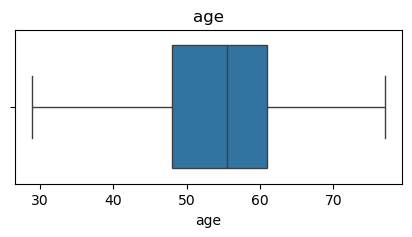

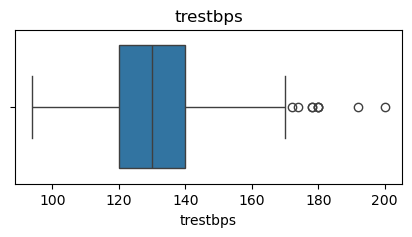

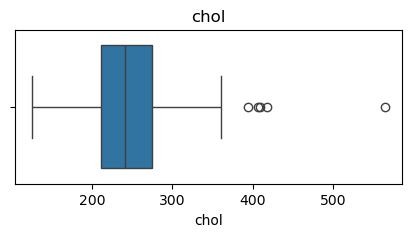

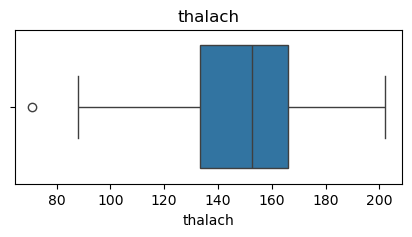

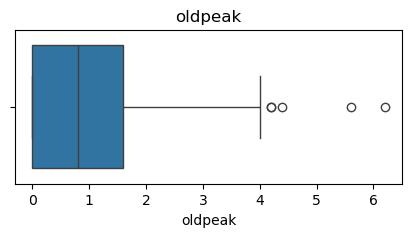

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['age','trestbps','chol','thalach','oldpeak']

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [14]:
df.info()
df.isnull().sum()
df.duplicated().sum()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


(302, 14)

In [15]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [16]:
X = df.drop('target', axis=1)

y = df['target']

In [17]:
print(X.shape)
print(y.shape)

(302, 13)
(302,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
print(X_train.shape)
print(X_test.shape)

(241, 13)
(61, 13)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [21]:
X_train_scaled

array([[-1.350641  ,  0.73145871,  0.        , ...,  0.96543644,
        -0.68348955, -0.54576155],
       [ 1.48742624,  0.73145871,  0.9664929 , ..., -0.68470669,
        -0.68348955,  1.14050171],
       [ 1.37826981,  0.73145871, -0.9664929 , ..., -0.68470669,
         1.35010281,  1.14050171],
       ...,
       [ 1.59658267,  0.73145871,  1.9329858 , ..., -0.68470669,
         0.33330663, -0.54576155],
       [ 0.72333121,  0.73145871,  1.9329858 , ..., -0.68470669,
         1.35010281, -0.54576155],
       [ 0.94164408, -1.36713116,  0.        , ...,  0.96543644,
         1.35010281, -0.54576155]])

In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [23]:
lr_pred = lr.predict(X_test_scaled)

In [24]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.819672131147541


In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

print(cm)

[[24  5]
 [ 6 26]]


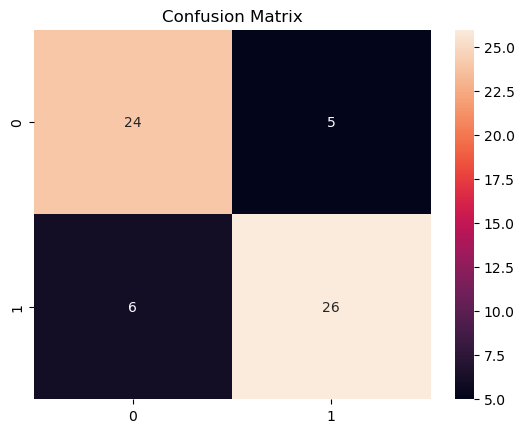

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.title("Confusion Matrix")
plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        29
           1       0.84      0.81      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



In [28]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [29]:
dt_acc = accuracy_score(
    y_test,
    dt_pred
)

print(dt_acc)

0.7704918032786885


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [31]:
rf_pred = rf.predict(X_test)

In [32]:
rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(rf_acc)

0.8688524590163934


In [33]:
print("Logistic Regression :", lr_acc)

print("Decision Tree :", dt_acc)

print("Random Forest :", rf_acc)


Logistic Regression : 0.819672131147541
Decision Tree : 0.7704918032786885
Random Forest : 0.8688524590163934


In [34]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

     Feature  Importance
7    thalach    0.123093
9    oldpeak    0.113440
11        ca    0.111613
2         cp    0.110655
12      thal    0.100442
0        age    0.100309
4       chol    0.081189
3   trestbps    0.069357
8      exang    0.063221
10     slope    0.056294
1        sex    0.038493
6    restecg    0.020906
5        fbs    0.010988


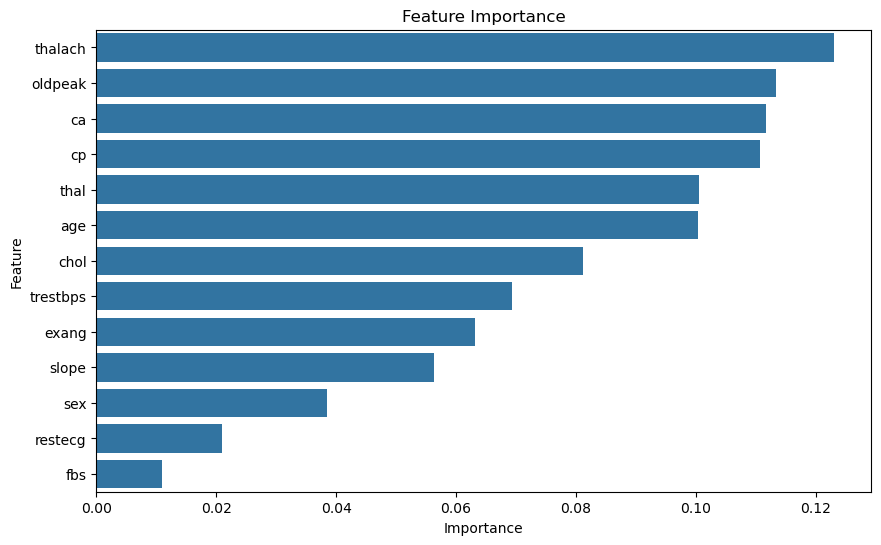

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

In [36]:
print("LR:", lr_acc)
print("DT:", dt_acc)
print("RF:", rf_acc)

LR: 0.819672131147541
DT: 0.7704918032786885
RF: 0.8688524590163934


In [37]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(cv_scores)
print("Average Accuracy:", cv_scores.mean())


[0.80327869 0.90163934 0.83333333 0.8        0.78333333]
Average Accuracy: 0.8243169398907104


In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X,y)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 200}
0.8475956284153006


In [39]:
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=2,
    random_state=42
)

best_rf.fit(X,y)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [40]:
import pickle

pickle.dump(
    best_rf,
    open("heart_model.pkl","wb")
)

In [41]:
pickle.dump(
    scaler,
    open("scaler.pkl","wb")
)

In [42]:
model = pickle.load(
    open("heart_model.pkl","rb")
)

sample = X.iloc[[0]]

prediction = model.predict(sample)

print(prediction)

[1]


In [43]:
def predict_heart_disease(data):
    
    prediction = model.predict(data)
    
    if prediction[0] == 1:
        return "Heart Disease Detected"
    else:
        return "No Heart Disease"

In [44]:
predict_heart_disease(sample)

'Heart Disease Detected'

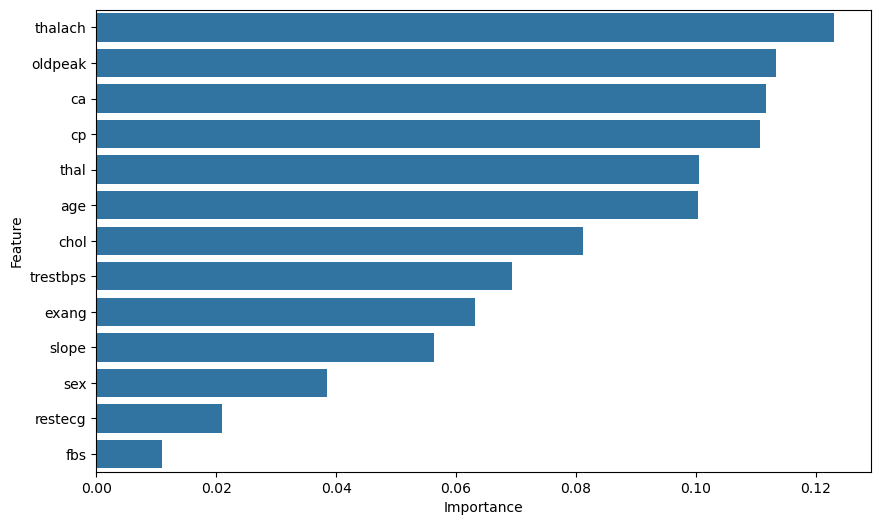

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.savefig("feature_importance.png")
plt.show()